# Baseline IDS — Approach 3: Pooled Multi-File Training + Held-Out File Testing

Third baseline data strategy, compared against:
- Approach 1: targeted sampling, 10 files, 2,000 common rows/file (see Baseline_IDS_Notes.docx)
- Approach 2: single whole file, Merged01.csv, internal 80/20 split (see baseline_analysis.ipynb)

This notebook: trains on a pooled, rare-class-complete sample from Merged01-10 (10,000 common rows/file), then tests on Merged11.csv **in full** — a file never seen during training. This is a genuine generalization test, unlike Approaches 1 and 2 which both evaluate on a split of the same file(s) they trained on.

In [1]:
import pandas as pd
import numpy as np
import glob
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, f1_score, balanced_accuracy_score
)
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
print('Imports OK')

Imports OK


## 1. Load Training Pool (Merged01-10) and Held-Out Test File (Merged11)

In [2]:
RARE_CLASSES = [
    'SQLINJECTION', 'UPLOADING_ATTACK', 'XSS',
    'COMMANDINJECTION', 'BACKDOOR_MALWARE', 'BROWSERHIJACKING',
    'DICTIONARYBRUTEFORCE', 'RECON-PINGSWEEP'
]
COMMON_SAMPLE = 10000  # up from 2,000/file in Approach 1 — richer rare-class coverage

train_files = sorted(glob.glob('../datasets/cicids2023/Merged*.csv'))[:10]
print('Training files:', [f.split('/')[-1] for f in train_files])

dfs = []
for f in train_files:
    df_full = pd.read_csv(f)
    rare_mask = df_full['Label'].isin(RARE_CLASSES)
    df_rare   = df_full[rare_mask]
    df_common = df_full[~rare_mask].sample(
        n=min(COMMON_SAMPLE, (~rare_mask).sum()), random_state=42
    )
    dfs.append(pd.concat([df_rare, df_common], ignore_index=True))
    del df_full
train_df = pd.concat(dfs, ignore_index=True)
del dfs
print(f'Pooled training rows: {len(train_df):,}')

# Held-out test file — NOT used in training at all
test_df = pd.read_csv('../datasets/cicids2023/Merged11.csv')
print(f'Held-out test rows (Merged11.csv, full): {len(test_df):,}')

Training files: ['Merged01.csv', 'Merged02.csv', 'Merged03.csv', 'Merged04.csv', 'Merged05.csv', 'Merged06.csv', 'Merged07.csv', 'Merged08.csv', 'Merged09.csv', 'Merged10.csv']
Pooled training rows: 106,336
Held-out test rows (Merged11.csv, full): 909,761


Pooled training rows: 106,336


Held-out test rows (Merged11.csv, full): 909,761


In [3]:
def clean(df):
    df = df.dropna()
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    return df

train_df = clean(train_df)
test_df = clean(test_df)
print(f'After cleaning -> train: {len(train_df):,}  test: {len(test_df):,}')

train_labels = set(train_df['Label'].unique())
test_df = test_df[test_df['Label'].isin(train_labels)].copy()
print(f'Classes in training pool: {len(train_labels)}')
print(f'Test rows after restricting to trained classes: {len(test_df):,}')

After cleaning -> train: 106,333  test: 909,744
Classes in training pool: 34
Test rows after restricting to trained classes: 909,744


## 2. Encoding

In [4]:
encoder = LabelEncoder()
encoder.fit(sorted(train_labels))
train_df['Label_encoded'] = encoder.transform(train_df['Label'])
test_df['Label_encoded']  = encoder.transform(test_df['Label'])

train_df['Binary_Label'] = train_df['Label'].apply(lambda x: 'Normal' if x=='BENIGN' else 'Attack')
test_df['Binary_Label']  = test_df['Label'].apply(lambda x: 'Normal' if x=='BENIGN' else 'Attack')
train_df['Binary_encoded'] = (train_df['Binary_Label']=='Attack').astype(int)
test_df['Binary_encoded']  = (test_df['Binary_Label']=='Attack').astype(int)

feature_cols = [c for c in train_df.columns if c not in ['Label','Binary_Label','Label_encoded','Binary_encoded']]
X_train = train_df[feature_cols]
X_test  = test_df[feature_cols]
print(f'Features: {len(feature_cols)}')

Features: 39


## 3. Binary Classification (Normal vs Attack) — Held-Out Test

In [5]:
y_train_b = train_df['Binary_encoded']
y_test_b  = test_df['Binary_encoded']

rf_b = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=2, class_weight='balanced')
rf_b.fit(X_train, y_train_b)
pred_b = rf_b.predict(X_test)

acc_b = accuracy_score(y_test_b, pred_b)
bal_b = balanced_accuracy_score(y_test_b, pred_b)
f1_b  = f1_score(y_test_b, pred_b, average='weighted')

print(f'Accuracy          : {acc_b*100:.2f}%')
print(f'Balanced Accuracy : {bal_b*100:.2f}%')
print(f'F1 (weighted)     : {f1_b:.4f}')
print()
print(classification_report(y_test_b, pred_b, target_names=['Normal','Attack'], zero_division=0))

Accuracy          : 99.04%
Balanced Accuracy : 94.11%
F1 (weighted)     : 0.9908

              precision    recall  f1-score   support

      Normal       0.75      0.89      0.81     21213
      Attack       1.00      0.99      1.00    888531

    accuracy                           0.99    909744
   macro avg       0.87      0.94      0.90    909744
weighted avg       0.99      0.99      0.99    909744



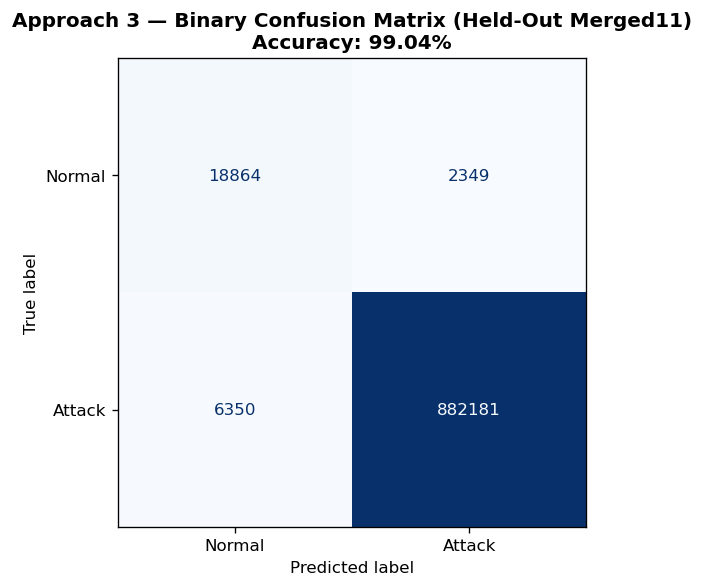

In [6]:
fig, ax = plt.subplots(figsize=(6,5))
cm = confusion_matrix(y_test_b, pred_b)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal','Attack'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Approach 3 — Binary Confusion Matrix (Held-Out Merged11)\nAccuracy: {acc_b*100:.2f}%', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/approach3_binary_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 4. Multi-Class Classification (34 Classes) — Held-Out Test

In [7]:
y_train_m = train_df['Label_encoded']
y_test_m  = test_df['Label_encoded']

rf_m = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=2, class_weight='balanced')
rf_m.fit(X_train, y_train_m)
pred_m = rf_m.predict(X_test)

acc_m = accuracy_score(y_test_m, pred_m)
bal_m = balanced_accuracy_score(y_test_m, pred_m)
f1_macro = f1_score(y_test_m, pred_m, average='macro', zero_division=0)
f1_w = f1_score(y_test_m, pred_m, average='weighted', zero_division=0)

print(f'Accuracy          : {acc_m*100:.2f}%')
print(f'Balanced Accuracy : {bal_m*100:.2f}%')
print(f'Macro F1          : {f1_macro:.4f}   <-- main metric')
print(f'Weighted F1       : {f1_w:.4f}')
print()
print(classification_report(y_test_m, pred_m, target_names=encoder.classes_, zero_division=0))

Accuracy          : 75.43%
Balanced Accuracy : 61.25%
Macro F1          : 0.5520   <-- main metric
Weighted F1       : 0.7536

                         precision    recall  f1-score   support

       BACKDOOR_MALWARE       0.01      0.17      0.03        58
                 BENIGN       0.85      0.69      0.77     21213
       BROWSERHIJACKING       0.04      0.41      0.07       130
       COMMANDINJECTION       0.04      0.33      0.08        83
 DDOS-ACK_FRAGMENTATION       0.99      0.99      0.99      5508
        DDOS-HTTP_FLOOD       0.77      0.64      0.70       578
        DDOS-ICMP_FLOOD       1.00      1.00      1.00    138965
DDOS-ICMP_FRAGMENTATION       0.98      0.99      0.98      8845
      DDOS-PSHACK_FLOOD       1.00      1.00      1.00     79750
       DDOS-RSTFINFLOOD       1.00      1.00      1.00     78596
         DDOS-SLOWLORIS       0.53      0.75      0.62       458
DDOS-SYNONYMOUSIP_FLOOD       0.47      0.69      0.56     69475
         DDOS-SYN_FLOOD    

### Multi-Class Confusion Matrix

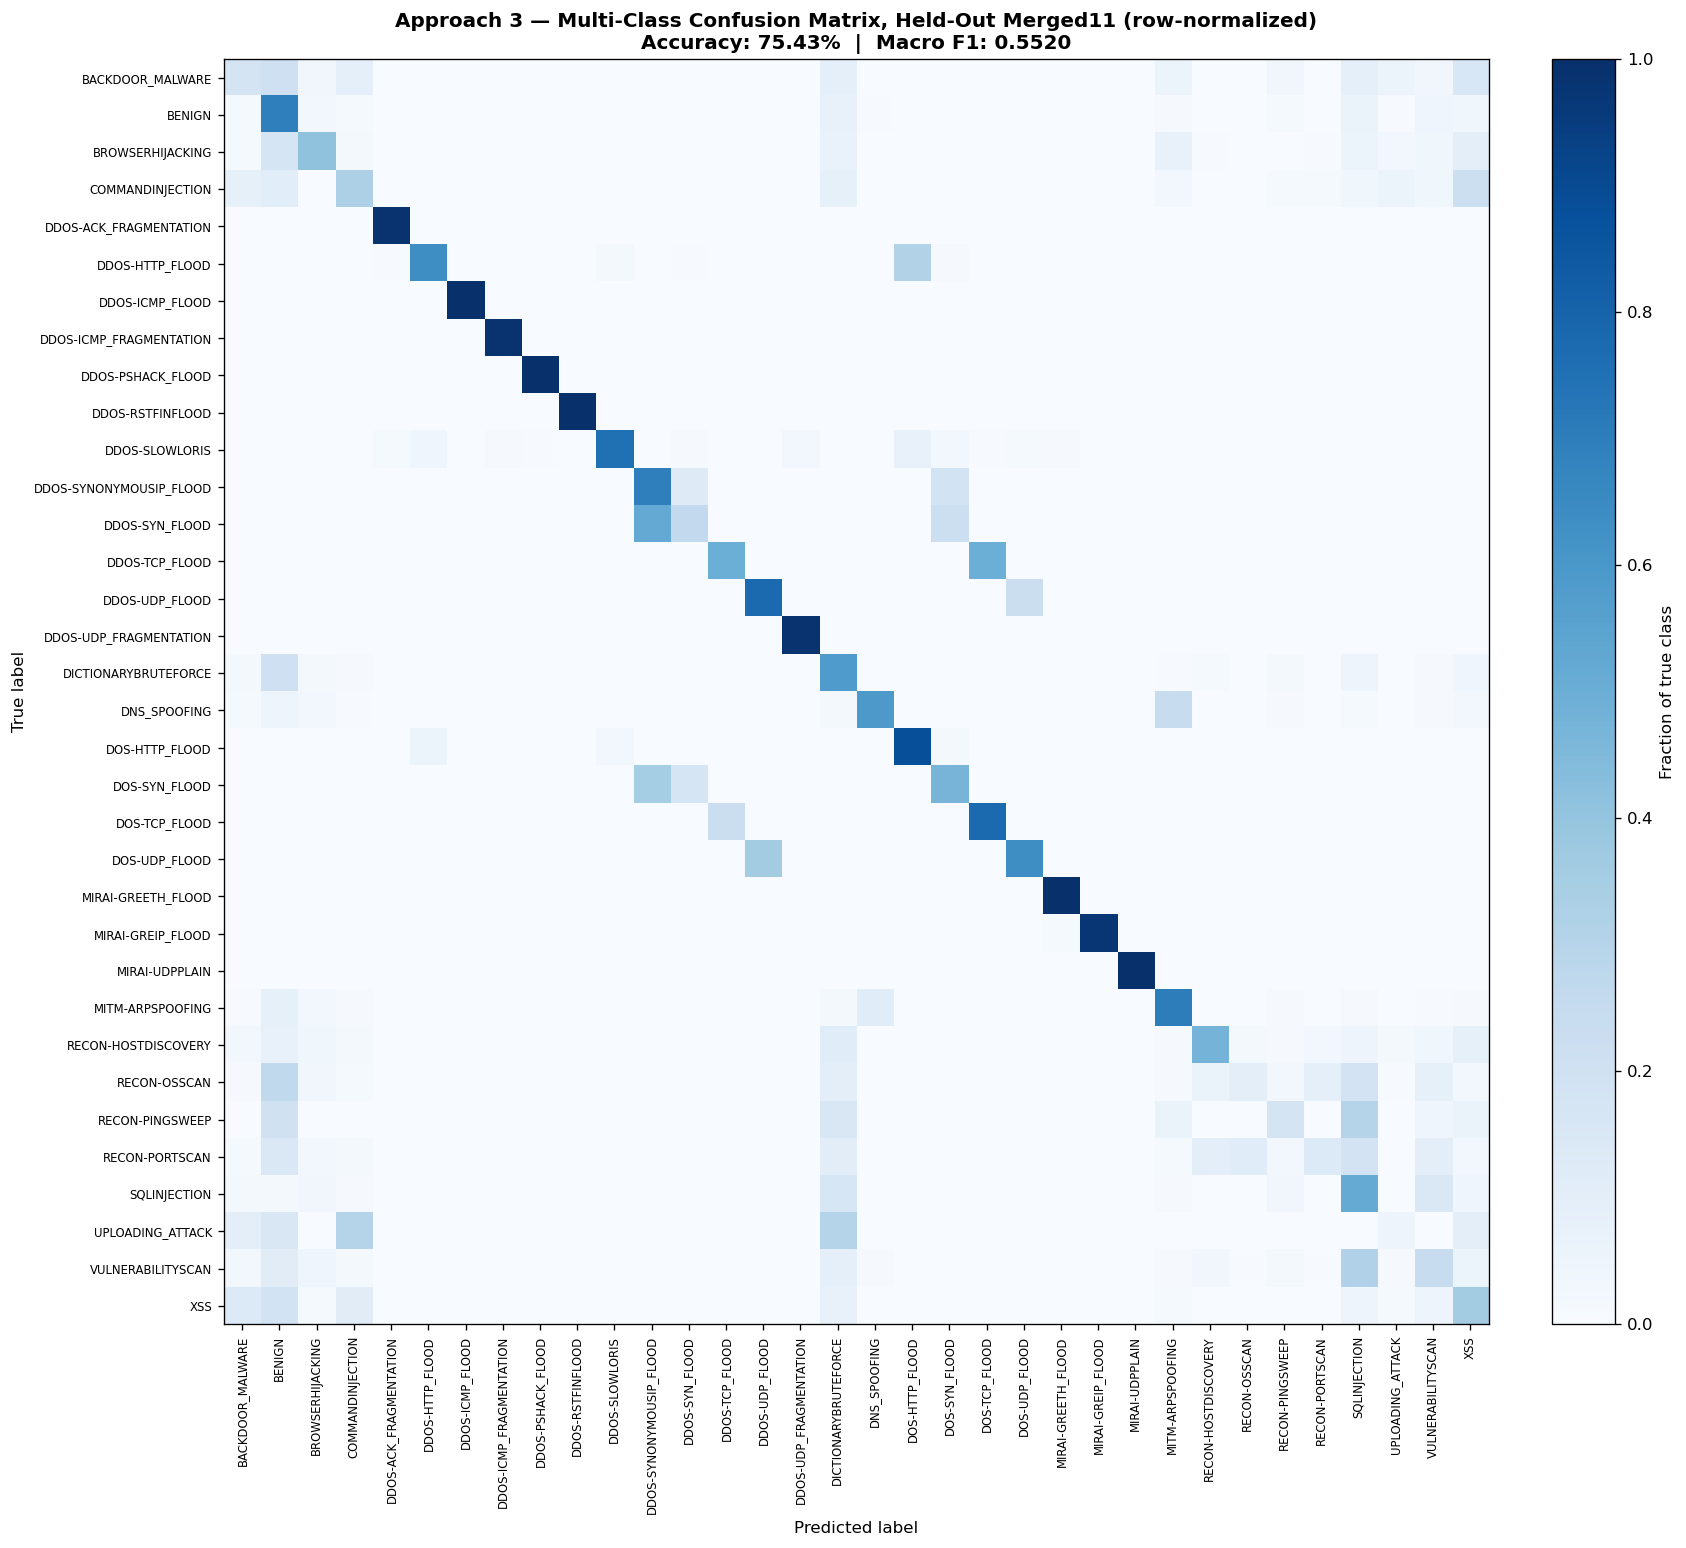

In [8]:
cm_multi3 = confusion_matrix(y_test_m, pred_m, labels=range(len(encoder.classes_)), normalize='true')
fig, ax = plt.subplots(figsize=(15, 13))
im = ax.imshow(cm_multi3, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(encoder.classes_)))
ax.set_yticks(range(len(encoder.classes_)))
ax.set_xticklabels(encoder.classes_, rotation=90, fontsize=7)
ax.set_yticklabels(encoder.classes_, fontsize=7)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title(f'Approach 3 — Multi-Class Confusion Matrix, Held-Out Merged11 (row-normalized)\nAccuracy: {acc_m*100:.2f}%  |  Macro F1: {f1_macro:.4f}', fontweight='bold')
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Fraction of true class')
plt.tight_layout()
plt.savefig('../results/approach3_multiclass_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Summary — Approach 3 Results

In [9]:
print('   APPROACH 3 RESULTS SUMMARY — Pooled Training + Held-Out File Test')
print(f'Training       : Merged01-10, rare-complete + 10,000 common rows/file = {len(train_df):,} rows')
print(f'Testing        : Merged11.csv, full, unseen file = {len(test_df):,} rows')
print(f'Classes        : {len(encoder.classes_)}')
print()
print(f'Binary  Balanced Accuracy : {bal_b*100:.2f}%')
print(f'Binary  F1 (weighted)     : {f1_b:.4f}')
print()
print(f'Multi   Balanced Accuracy : {bal_m*100:.2f}%')
print(f'Multi   Macro F1          : {f1_macro:.4f}')
print(f'Multi   Weighted F1       : {f1_w:.4f}')

   APPROACH 3 RESULTS SUMMARY — Pooled Training + Held-Out File Test
Training       : Merged01-10, rare-complete + 10,000 common rows/file = 106,333 rows
Testing        : Merged11.csv, full, unseen file = 909,744 rows
Classes        : 34

Binary  Balanced Accuracy : 94.11%
Binary  F1 (weighted)     : 0.9908

Multi   Balanced Accuracy : 61.25%
Multi   Macro F1          : 0.5520
Multi   Weighted F1       : 0.7536
